C:\Users\He Entong\AppData\Local\Temp\ipykernel_10828\3442941838.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


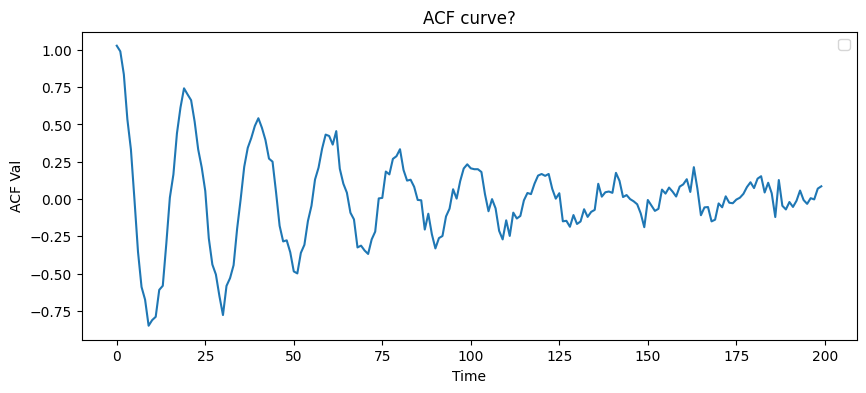

ACF data exported to acf_data.txt


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Parameters
T = 10.0      # Total time horizon
tau = 0.05    # Step size
decay = 0.3   # Exponential decay rate
freq = 1.0    # Oscillation frequency

# Time array
times = np.arange(0, int(T / tau))

# ACF-like curve: Exponential decay times a cosine (damped oscillation)
acf = np.exp(-decay * times * tau) * np.cos(2 * np.pi * freq * times * tau)

# Optional: Add some noise for realism
acf += 0.05 * np.random.randn(len(acf))

# Plot
plt.figure(figsize=(10,4))
plt.plot(times, acf)
plt.xlabel('Time')
plt.ylabel('ACF Val')
plt.title('ACF curve?')
plt.legend()
plt.show()


# export to a file to be read by C
path = 'acf_data.txt'
with open(path, 'w') as f:
    for t, a in zip(times, acf):
        f.write(f"{a}\n")
print(f"ACF data exported to {path}")

In [44]:
benchmark_path = './evaluation/CSI20250227_191018.csv'
csi_data = pd.read_csv(benchmark_path)
csi_data = csi_data['data'].apply(lambda x: eval(x)).to_numpy()
time_horizon = csi_data.shape[0]
num_subcarriers = len(csi_data[0]) // 2

In [67]:
csi_amp = np.zeros(time_horizon)
for i in range(time_horizon):
    for j in range(num_subcarriers):
        csi_amp_real = csi_data[i][2 * j]
        csi_amp_imag = csi_data[i][2 * j + 1]
        csi_amp[i] += (csi_amp_real ** 2 + csi_amp_imag ** 2) / 1e5



### Note ###
We use the autocorrelation function
$$
ACF_j = \frac{Cov(X_t, X_{t-j})}{Var(X_t)} = \frac{\sum_{t=j}^{n} (X_t - \bar{X})(X_{t-j} - \bar{X})}{\sum_{t=1}^{n} (X_t - \bar{X})^2}.
$$

In [78]:
def ACF(data):
    data_len = len(data)
    acf = np.zeros(data_len)
    data_mean = np.mean(data)
    data_shifted = data - data_mean
    for i in range(data_len):
        acf[i] = np.sum(data_shifted[:data_len - i] * data_shifted[i:])
    acf /= (np.var(data) * data_len)
    return acf

ACF data exported to acf_data.txt


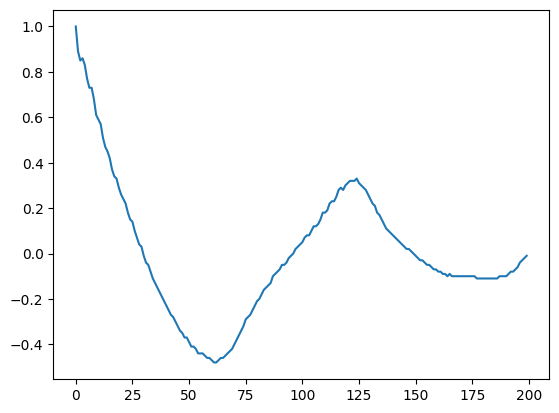

In [134]:
# window_size = 2000
# step_size = 50
# window_num = (time_horizon - window_size) // step_size + 1
# window_index = 30
# example_window = csi_amp[window_index * step_size: window_index * step_size + window_size]
# print(len(example_window))
# example_acf = ACF(example_window)
# print(len(example_acf))
# plt.figure(figsize=(50, 10))


example_acf = [1.00, 0.89, 0.85, 0.86, 0.83, 0.77, 0.73, 0.73, 0.68, 0.61, 0.59, 0.57, 0.51, 0.47, 0.45, 0.42, 0.37, 0.34, 0.33, 0.29, 0.26, 0.24, 0.22, 0.18, 0.15, 0.14, 0.10, 0.07, 0.04, 0.03, -0.01, -0.04, -0.05, -0.08, -0.11, -0.13, -0.15, -0.17, -0.19, -0.21, -0.23, -0.25, -0.27, -0.28, -0.30, -0.32, -0.34, -0.35, -0.37, -0.37, -0.39, -0.41, -0.41, -0.42, -0.44, -0.44, -0.44, -0.45, -0.46, -0.46, -0.47, -0.48, -0.48, -0.47, -0.46, -0.46, -0.45, -0.44, -0.43, -0.42, -0.40, -0.38, -0.36, -0.34, -0.32, -0.29, -0.28, -0.27, -0.25, -0.23, -0.21, -0.20, -0.18, -0.16, -0.15, -0.14, -0.13, -0.10, -0.09, -0.08, -0.07, -0.05, -0.05, -0.04, -0.02, -0.01, 0.00, 0.02,
            0.03, 0.04, 0.05, 0.07, 0.08, 0.08, 0.10, 0.12, 0.12, 0.13, 0.15, 0.18, 0.18, 0.19, 0.22, 0.23, 0.23, 0.25, 0.28, 0.29, 0.28, 0.30, 0.31, 0.32, 0.32, 0.32, 0.33, 0.31, 0.30, 0.29, 0.28, 0.26, 0.24, 0.22, 0.21, 0.18, 0.17, 0.15, 0.13, 0.11, 0.10, 0.09, 0.08, 0.07, 0.06, 0.05, 0.04, 0.03, 0.02, 0.02, 0.01, -0.00, -0.01, -0.02, -0.03, -0.03, -0.04, -0.05, -0.05, -0.06, -0.07, -0.07, -0.08, -0.08, -0.09, -0.09, -0.10, -0.09, -0.10, -0.10, -0.10, -0.10, -0.10, -0.10, -0.10, -0.10, -0.10, -0.10, -0.10, -0.11, -0.11, -0.11, -0.11, -0.11, -0.11, -0.11, -0.11, -0.11, -0.11, -0.10, -0.10, -0.10, -0.10, -0.09, -0.08, -0.08, -0.07, -0.06, -0.04, -0.03, -0.02, -0.01]
plt.plot(example_acf, label='ACF of example window')

# write the ACF to acf_data.txt
with open(path, 'w') as f:
    for a in example_acf:
        f.write(f"{a}\n")
print(f"ACF data exported to {path}")


In [132]:
%%bash
gcc -w -o PD peak_detection.c
./PD

Peak indices written to peak_indices.txt
Typical period min samples: 300, Typical period max samples: 600
First peak found at index: 406, data value: 0.025799
Estimated BPM: 14.778325


Peak indices read from peak_indices.txt: [4, 8, 11, 14, 17, 21, 26, 30, 34, 40, 43, 47, 58, 64, 71, 74, 78, 82, 86, 90, 94, 98]
Peak values: [0.39827060976093726, 0.1545728202909861, 0.06244033438475047, 0.049379840054539055, 0.15591827273633632, 0.02323700387572004, 0.10188328844409075, 0.07497569854094406, 0.06719109429769542, 0.015185783977196459, 0.07412720560546855, 0.08890252714900848, 0.09124831890522547, 0.07624758882737838, 0.08235320039555427, 0.08365429830093624, 0.09278019645278565, 0.08703406860965628, 0.06899529851577808, 0.06659485933701911, 0.039465448553847524, 0.019634423632348297]


C:\Users\He Entong\AppData\Local\Temp\ipykernel_138156\1517448407.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


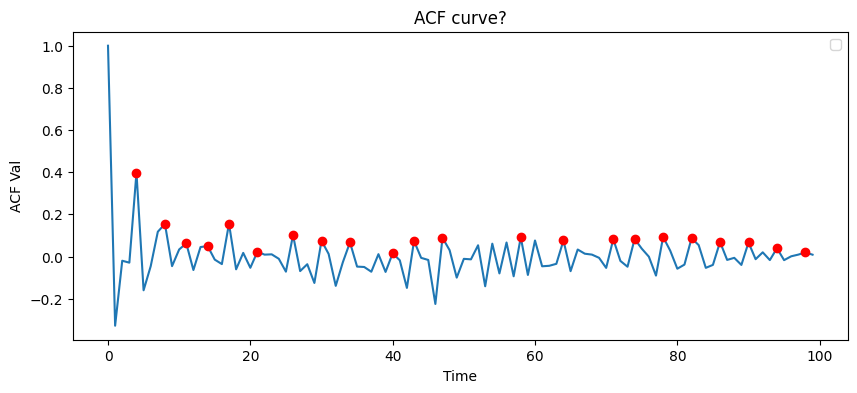

In [124]:
# write parsed peak indices from peak_indices.txt
peak_data_path = 'peak_indices.txt'
peak_indices = []
with open(peak_data_path, 'r') as f:
    for line in f:
        peak_indices.append(int(line.strip()))
print(f"Peak indices read from {peak_data_path}: {peak_indices}")

peaks_val = [
    float(example_acf[i]) for i in peak_indices if i < len(example_acf)
]

print(f"Peak values: {peaks_val}")


plt.figure(figsize=(10,4))
plt.plot([_ for _ in range(len(example_acf))], example_acf)
plt.xlabel('Time')
plt.ylabel('ACF Val')
plt.title('ACF curve?')
plt.legend()
plt.plot(peak_indices, peaks_val, 'ro', label='Peaks')

In [4]:
def acf_lag(data, lag):
    data_len = len(data)
    sum = 0
    mean = np.mean(data)
    data_removed_mean = data - mean
    for i in range(lag, data_len):
        sum += data_removed_mean[i - lag] * data_removed_mean[i]
    return sum

In [19]:
def smooth(data, window_length):
    data_len = len(data)
    if window_length % 2 == 1:
        window_length += 1
    half_window = window_length // 2
    new_data = np.zeros(data_len)
    
    for i in range(data_len):
        window_sum = 0.0
        window_count = 0
        for j in range(i - half_window, i + half_window + 1):
            if j >= 0 and j < data_len:
                window_sum += data[j]
                window_count += 1
        new_data[i] = window_sum / window_count
    return new_data

In [150]:
def save_acf(data, path):
    with open(path, 'w') as f:
        for a in data:
            f.write(f"{a}\n")
    print(f"ACF data exported to {path}")

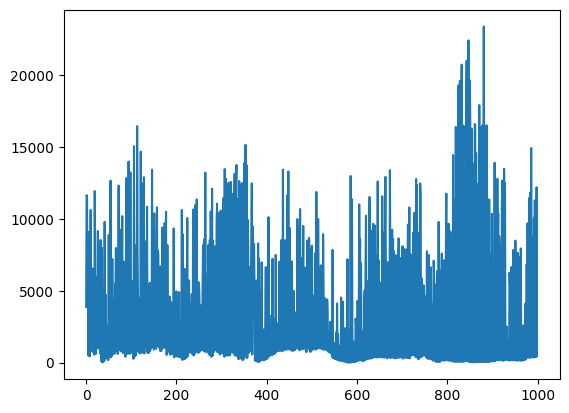

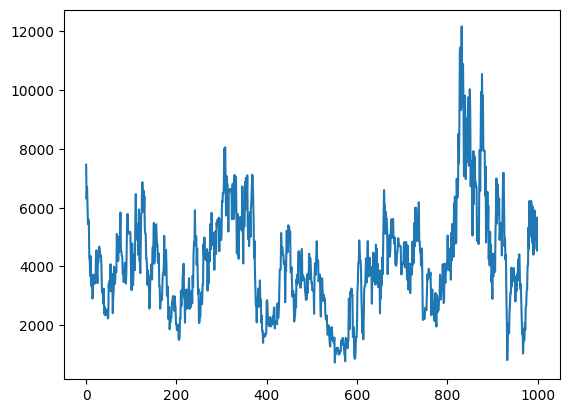

In [49]:
evaluation_set = pd.read_csv("evaluation/CSI20250227_191018.csv")

evaluation_set = evaluation_set['data'].apply(lambda x: np.array(eval(x))).to_numpy()

evaluation_set = evaluation_set[2000: 3000]

T = evaluation_set.shape[0]

num_subcarriers = evaluation_set[0].shape[0] // 2

csi_matrix = np.zeros((num_subcarriers, T))

for t in range(T):
    for sc in range(num_subcarriers):
        csi_matrix[sc][t] = evaluation_set[t][sc * 2] ** 2 + evaluation_set[t][sc * 2 + 1] ** 2


plt.plot(csi_matrix[1])
plt.show()
smoothed_csi = smooth(csi_matrix[1], 8)

plt.plot(smoothed_csi)
plt.show()

for sc in range(num_subcarriers):
    csi_matrix[sc] = smooth(csi_matrix[sc], 8)


acf_across_subcarrier = np.zeros((num_subcarriers, T))

for sc in range(num_subcarriers):
    for lag in range(T):
        acf_across_subcarrier[sc][lag] = acf_lag(csi_matrix[sc], lag)

In [44]:
# Parse the evaluation data with downsampling

csi_matrix_transpose = np.transpose(csi_matrix)
csi_matrix_transpose = csi_matrix_transpose.astype(np.int64)
print(csi_matrix_transpose[1])

with open("test_data_downsampled.txt", 'w') as f:
    cnt = 0
    for t_instance in csi_matrix_transpose:
        if cnt % 4 == 0:
            f.write(str(np.ndarray.tolist(t_instance)).strip(']').strip('[') + '\n')
        cnt += 1


print(cnt)
# plt.plot(csi_matrix[0])

[ 296  346  317  340  346  346  369  369  290  317  365  338  394  365
  365  288  340  369  392  369  317  317  317  356  337  337  306  320
  305  292  261  338  261  305  298  370  293  225  289  365  290  260
  305  293  333  298  298  265  229  281  272  232  250  205  193  205
  212    0    0    0  162  157  128  145  113   89   85   50   52   52
   58   37   17   13   17   13   25   40   40   50   81   82  101  170
  197  200  197  290  328  333  416  409  545  554  565  738  754  809
  916  977  857 1025 1138 1138 1192 1073 1241 1250 1297 1296 1296 1089
 1160 1105 1160  970 1049]
5004


In [50]:
acf_across_subcarrier_normalized = np.zeros((num_subcarriers, T))
for sc in range(num_subcarriers):
    for lag in range(1, T):
        acf_across_subcarrier_normalized[sc][lag] = acf_across_subcarrier[sc][lag] / acf_across_subcarrier[sc][0]
    acf_across_subcarrier_normalized[sc][0] = 1.0


print(acf_across_subcarrier_normalized)


[[1.00000000e+00 9.67173316e-01 9.58489895e-01 ... 2.22172181e-03
  1.99213188e-03 1.09217382e-03]
 [1.00000000e+00 9.12738826e-01 8.85113517e-01 ... 2.29766645e-03
  1.97069995e-03 4.52368777e-04]
 [1.00000000e+00 9.53784812e-01 9.43894038e-01 ... 1.00544950e-03
  7.97718518e-04 3.96191104e-04]
 ...
 [1.00000000e+00 9.03170069e-01 8.75978528e-01 ... 1.43861410e-02
  1.06417698e-02 2.46658066e-03]
 [1.00000000e+00 9.05129380e-01 8.73690553e-01 ... 1.55600322e-02
  1.20244320e-02 5.01962950e-03]
 [1.00000000e+00 9.53937552e-01 9.43511677e-01 ... 1.14739641e-02
  8.99275699e-03 4.28519383e-03]]


C:\Users\He Entong\AppData\Local\Temp\ipykernel_10828\1157321552.py:4: RuntimeWarning: invalid value encountered in scalar divide
  acf_across_subcarrier_normalized[sc][lag] = acf_across_subcarrier[sc][lag] / acf_across_subcarrier[sc][0]


9.546461886971311


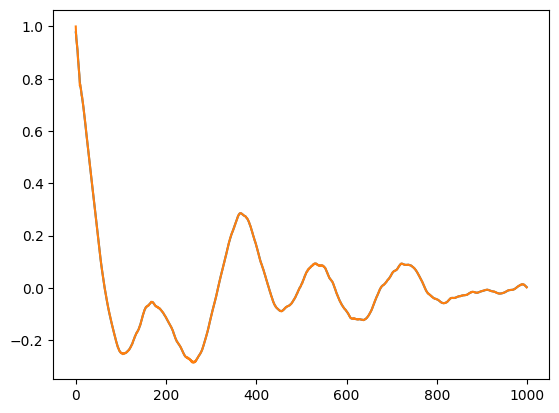

In [54]:
total_weight = 0.0
mrc_acf = np.zeros(T, np.float64)

acf_across_subcarrier_normalized_removenan = np.nan_to_num(acf_across_subcarrier_normalized)

acf_across_subcarrier_normalized_removenan = np.ndarray.tolist(acf_across_subcarrier_normalized_removenan)

acf_across_subcarrier_normalized_removenan = sorted(acf_across_subcarrier_normalized_removenan, key = lambda x: x[1], reverse=True)

sc_to_take = 10

acf_across_subcarrier_normalized_removenan = acf_across_subcarrier_normalized_removenan[:sc_to_take]

for sc in range(sc_to_take):
    total_weight += acf_across_subcarrier_normalized_removenan[sc][1]

print(total_weight)

for lag in range(T):
    time_total_acf = 0.0
    for sc in range(sc_to_take):
        time_total_acf += acf_across_subcarrier_normalized_removenan[sc][lag] * acf_across_subcarrier_normalized_removenan[sc][1] / total_weight
    mrc_acf[lag] = time_total_acf

smoothed_mrc_acf = smooth(mrc_acf, 1)
plt.plot(smoothed_mrc_acf)


plt.plot(mrc_acf)

In [9]:
path = "acf_data.txt"
example_acf = mrc_acf
with open(path, 'w') as f:
    for a in example_acf:
        f.write(f"{a}\n")
print(f"ACF data exported to {path}")

ACF data exported to acf_data.txt


[363]


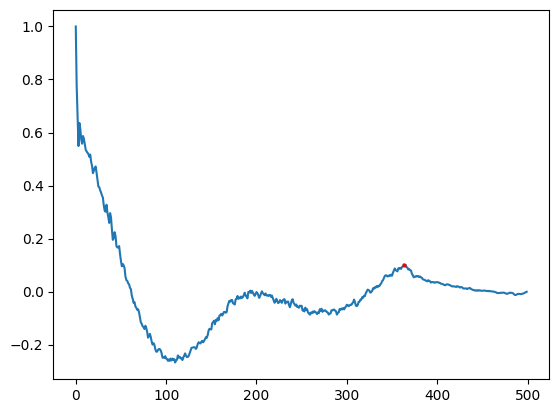

In [125]:
from scipy.signal import find_peaks
peaks = find_peaks(example_acf, prominence=0.1, height=0.05)[0]

print(peaks)

plt.plot(example_acf)
example_acf = np.array(example_acf)

plt.plot(peaks, example_acf[peaks], 'ro', markersize = 2)

In [ ]:
a = [1.00, 0.98, 0.96, 0.94, 0.93, 0.91, 0.89, 0.87, 0.85, 0.84, 0.82, 0.80, 0.78, 0.76, 0.75, 0.73, 0.71, 0.69, 0.67, 0.66, 0.64, 0.62, 0.60, 0.59, 0.57, 0.55, 0.53, 0.52, 0.50, 0.48, 0.46, 0.44, 0.42, 0.41, 0.39, 0.37, 0.35, 0.34, 0.32, 0.30, 0.28, 0.27, 0.25, 0.23, 0.21, 0.20, 0.18, 0.16, 0.14, 0.12, 0.10, 0.09, 0.07, 0.05, 0.03, 0.01, -0.00, -0.02, -0.04, -0.06, -0.08, -0.08, -0.08, -0.08, -0.08, -0.08, -0.08, -0.08, -0.09, -0.09, -0.09, -0.09, -0.09, -0.09, -0.09, -0.09, -0.10, -0.10, -0.10, -0.10, -0.10, -0.10, -0.10, -0.10, -0.11, -0.11, -0.11, -0.11, -0.11, -0.11, -0.11, -0.11, -0.12, -0.12, -0.12, -0.12, -0.12, -0.12, -0.12, -0.12, -0.13, -0.13, -0.13, -0.13, -0.13, -0.13, -0.13, -0.13, -0.14, -0.14, -0.14, -0.14, -0.14, -0.14, -0.14, -0.14, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.16, -0.16, -0.16, -0.16, -0.16, -
        0.16, -0.16, -0.16, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.18, -0.18, -0.18, -0.18, -0.18, -0.18, -0.18, -0.18, -0.19, -0.19, -0.19, -0.19, -0.19, -0.19, -0.19, -0.19, -0.20, -0.20, -0.20, -0.20, -0.20, -0.20, -0.20, -0.20, -0.21, -0.21, -0.21, -0.21, -0.21, -0.21, -0.21, -0.21, -0.22, -0.22, -0.22, -0.22, -0.22, -0.22, -0.22, -0.22, -0.23, -0.23, -0.23, -0.23, -0.23, -0.23, -0.23, -0.23, -0.24, -0.24, -0.24, -0.24, -0.24, -0.23, -0.23, -0.22, -0.22, -0.22, -0.21, -0.21, -0.20, -0.20, -0.20, -0.19, -0.19, -0.18, -0.18, -0.18, -0.17, -0.17, -0.16, -0.16, -0.16, -0.15, -0.15, -0.14, -0.14, -0.14, -0.13, -0.13, -0.12, -0.12, -0.12, -0.11, -0.11, -0.10, -0.10, -0.10, -0.09, -0.09, -0.08, -0.08, -0.08, -0.07, -0.07, -0.06, -0.06, -0.06, -0.05, -0.05, -0.04, -0.04, -0.04, -0.03, -0.03, -0.02, -0.02, -0.02, -0.01, -0.01, -0.00]

a_smooth = smooth(a, 4)

a_smooth = np.array(a_smooth)
# plt.plot(a)
save_acf(a, 'acf_data.txt')
peaks = find_peaks(a_smooth, prominence=0.05)[0]

plt.plot(a_smooth)

plt.plot(peaks, a_smooth[peaks], 'ro')

print(a_smooth[peaks])

NameError: name 'save_acf' is not defined

In [164]:
smoothed_from_c = []
with open("smoothed_data.txt", 'r') as f:
    for line in f:
        smoothed_from_c.append(float(line.strip()))


smoothed_from_c = np.array(smoothed_from_c)
smoothed_from_c[[48, 49, 50, 51, 52]]

array([0.140588, 0.122941, 0.104706, 0.086471, 0.068235])

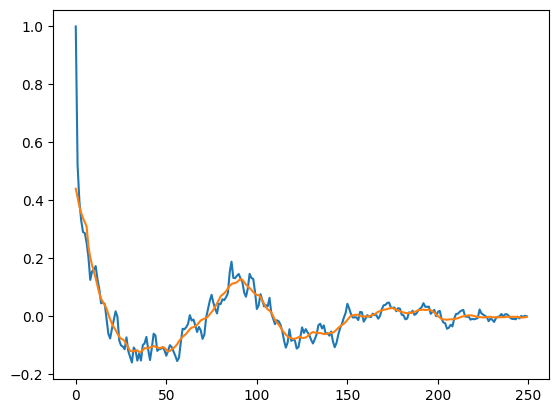

In [61]:
a = [1.000000,0.521735,0.396896,0.330189,0.290278,0.286757,0.252881,0.203112,0.125258,0.154996,0.159523,0.173023,0.126511,0.092925,0.044519,0.046809,0.042637,-0.008643,-0.061210,-0.076832,-0.042529,-0.012790,0.016756,-0.001547,-0.083750,-0.100904,-0.104989,-0.114053,-0.073121,-0.120707,-0.139953,-0.159816,-0.108120,-0.117683,-0.153420,-0.128962,-0.153116,-0.100085,-0.093883,-0.071581,-0.115115,-0.151470,-0.109888,-0.060507,-0.066515,-0.119765,-0.113769,-0.112955,-0.106550,-0.118054,-0.136469,-0.118522,-0.100088,-0.106947,-0.121664,-0.137253,-0.154884,-0.143432,-0.089519,-0.043506,-0.044949,-0.038084,-0.026374,0.003618,-0.015077,-0.011641,-0.031831,-0.054513,-0.037031,-0.048670,-0.078329,-0.064002,-0.004668,0.024226,0.052801,0.073781,0.046323,0.025510,0.009452,0.043056,0.041916,0.058359,0.055467,0.065625,0.079540,0.150955,0.188157,0.132343,0.131254,0.139701,0.145600,0.129686,0.118210,0.081618,0.067092,0.095105,0.146142,0.131564,0.128734,0.083201,0.024793,0.037231,0.076008,0.054952,0.033711,0.037860,0.034332,0.063158,0.009645,-0.008197,-0.027555,-0.014105,-0.017060,-0.028719,-0.050586,-0.083393,-0.108512,-0.091155,-0.045320,-0.085239,-0.080296,-0.084131,-0.111797,-0.106524,-0.073267,-0.038602,-0.057894,-0.044723,-0.056013,-0.065166,-0.082321,-0.094214,-0.079284,-0.062722,-0.030862,-0.026090,-0.042265,-0.031910,-0.061659,-0.058707,-0.067176,-0.053194,-0.086768,-0.107117,-0.091859,-0.063090,-0.040317,-0.026682,-0.005562,0.010901,0.042697,0.026036,0.006916,-0.004835,-0.003673,-0.003998,-0.013385,0.014600,0.013672,-0.018814,-0.008399,0.003516,-0.001363,-0.003133,0.008824,0.003578,0.003477,-0.008627,0.000630,0.023850,0.037597,0.039124,0.045805,0.047124,0.029801,0.028699,0.029831,0.017182,0.027657,0.025981,0.005041,0.002968,-0.010814,-0.008318,0.013120,0.010796,0.018825,0.004470,0.008531,0.018423,0.025104,0.031090,0.044820,0.032460,0.032318,0.032940,0.008141,0.014971,0.021572,-0.000278,0.015003,0.018374,-0.008893,-0.021705,-0.024306,-0.043514,-0.040049,-0.029549,-0.035201,-0.007913,0.007585,0.008419,0.015018,0.019168,0.021783,-0.001188,-0.002119,-0.001897,-0.011909,-0.009216,-0.010895,-0.008632,-0.006196,0.023033,0.009713,0.005527,0.001708,-0.003055,-0.017317,-0.008200,-0.012329,-0.019754,-0.007203,-0.002113,-0.001003,0.007547,-0.001172,0.006254,0.006777,0.002119,-0.006086,-0.009441,-0.009497,-0.010735,-0.001433,-0.007901,0.000967,-0.002563,0.001391,-0.000597,]

plt.plot(a)

a = smooth(a, 12)

plt.plot(a)